In [ ]:
import pandas as pd
from itables import init_notebook_mode
import plotnine as pn
init_notebook_mode(all_interactive=True)
import numpy as np
from adjustText import adjust_text
import matplotlib.pyplot as plt

In [3]:
py_or_res = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/or_variants.parquet")


In [4]:
or_output = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/output.parquet")

In [5]:
input_data = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/raw_filtered_input.parquet")

In [6]:
gene_id = "ENSG00000117118.5"
raw = input_data[[gene_id]]
# raw

In [22]:
raw_dt = raw.T.rename(columns={gene_id: "raw_expression"})

In [7]:
def _calculate_expected_log_geometric_mean_per_gene(output_ae: pd.DataFrame, lower_bound: float = 0.5):
    """
    Calculates the expectedLogGeomMean as defined in OUTRIDER.
    
    Args:
        output_ae (pd.DataFrame): The output DataFrame (normalization factors).
                                  Rows = Genes, Columns = Samples.
        lower_bound (float): The epsilon value to replace zeros/small values.
        
    Returns:
        pd.DataFrame: The expected log geometric mean per gene.
    """
    floored_output = output_ae.clip(lower=lower_bound)
    log_output = np.log(floored_output)
    mean_log = log_output.mean(axis=1, skipna=True)
    expected_log_geometric_mean = np.exp(mean_log)
    return expected_log_geometric_mean


In [8]:
gene_output = or_output[or_output["proteinID"] == gene_id]

gene_output = gene_output.set_index("proteinID")
raw = raw.T


expected_log_geometric_mean = _calculate_expected_log_geometric_mean_per_gene(gene_output)


In [9]:

min_epsilon = 0.5    
normalization_factors = gene_output.clip(lower=min_epsilon)

normalized_counts = raw / normalization_factors
output_data =  normalized_counts.multiply(expected_log_geometric_mean, axis=0)


In [10]:
df = output_data.T
df = df.sort_values(gene_id)
df["Rank"] = [i+1 for i in range(df.shape[0])]
#df["sampleID"] = df.index
# df.index=None
df.reset_index(level=0, inplace=True)
df = df.merge(py_or_res[py_or_res["geneID"] == gene_id], how="left", on="sampleID")
df = df.merge(raw_dt, on="sampleID")

In [ ]:
np.mean(raw.values)

In [ ]:
df[["sampleID", "Outlier status", "padjust", gene_id]]

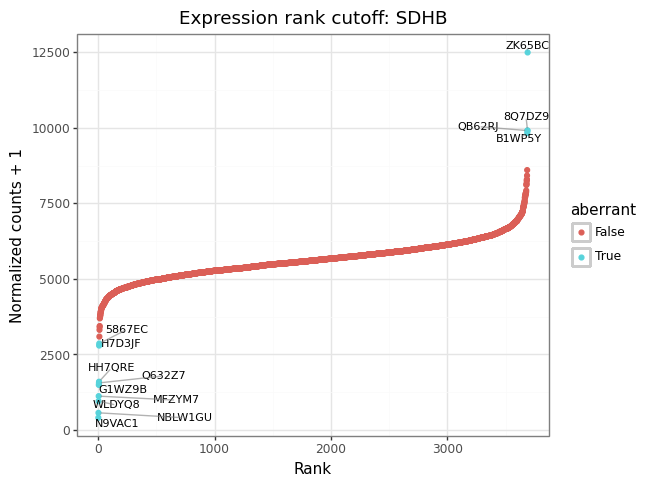

In [25]:
p = (pn.ggplot(df) +
     pn.geom_point(pn.aes(x = "Rank", y=gene_id, color="aberrant")) + 
     pn.labs(y="Normalized counts + 1", title = "Expression rank cutoff: SDHB") +
     pn.theme_bw()
    )

fig = p.draw()
ax = fig.axes[0]

# extract aberrant points
aberrant_df = df[df["aberrant"]]

texts = []
for _, row in aberrant_df.iterrows():
    texts.append(
        ax.text(
            row["Rank"],
            row[gene_id],
            row["sampleID"],
            fontsize=8
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray", alpha=0.6),
    expand_text=(1.2, 1.3)
)

# 🔑 show the *correct* figure
fig

In [26]:
df = df.sort_values("raw_expression")
df["raw_rank"] = [i + 1 for i in range(df.shape[0])]


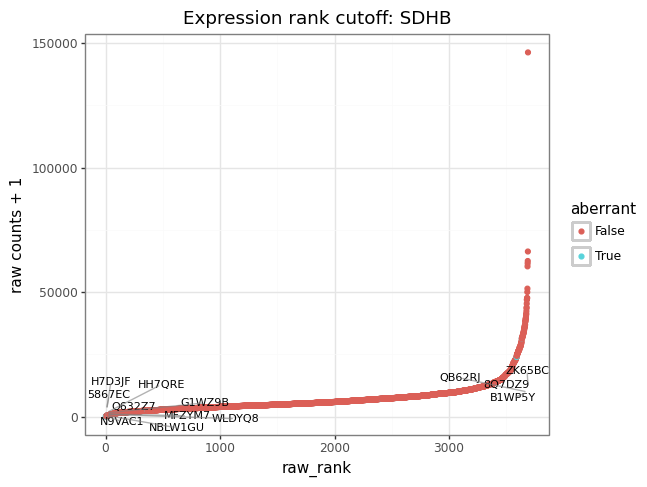

In [27]:
p = (pn.ggplot(df) +
     pn.geom_point(pn.aes(x = "raw_rank", y="raw_expression", color="aberrant")) + 
     pn.labs(y="raw counts + 1", title = "Expression rank cutoff: SDHB") +
     pn.theme_bw()
    )

fig = p.draw()
ax = fig.axes[0]

# extract aberrant points
aberrant_df = df[df["aberrant"]]

texts = []
for _, row in aberrant_df.iterrows():
    texts.append(
        ax.text(
            row["Rank"],
            row[gene_id],
            row["sampleID"],
            fontsize=8
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray", alpha=0.6),
    expand_text=(1.2, 1.3)
)

# 🔑 show the *correct* figure
fig

In [42]:
gene_id = "ENSG00000000003.10"
gene_res = py_or_res[py_or_res["geneID"] == gene_id]
gene_res["log_exp"] = np.log(gene_res["PROTEIN_EXPECTED_LOG2INT"] + 1)
gene_res = gene_res.sort_values("log_exp")

gene_res["Rank"] = [i + 1 for i in range(gene_res.shape[0])]


/tmp/ipykernel_2891384/1408577857.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
